In [20]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Latex, HTML, Math, display, Markdown
from uncertainties import ufloat
from uncertainties.umath import sqrt
from uncertainties import unumpy as unp
from scipy.stats import linregress
from scipy.optimize import curve_fit
from uncertainties.umath import *
from scipy import constants as const 
from uncertainties.umath import atan, degrees
import math
from matplotlib.patches import Rectangle
from matplotlib.ticker import MaxNLocator
from lmfit import Model

Model(lambda x: print(x))

Model(<lambda>)

# PW10 - Thermodynamik

$$\text{Anna Lechner, Paula Erhard}$$

## Wärmekapazität und spezifische Wärme

### Versuchsaufbau und Durchführung



### Wichtige Formeln und Zusammenhänge



### Verwendete Geräte und Unsicherheiten 


In [21]:
# Experiment 1: Wärmekapazität und spezifische 


m_w =      #Masse Wasser [kg]
C_k = ufloat(135, 10)       #Wärmekapazität Kalorimeter [J/K]

T0 =        #Anfangstemperatur [°C]
U0 =        #Anfangspannung [V]
I0 =       #Anfansstrom [A]

U_t =          #Endspannung [V]
I_t =          #Endsstrom [A]

df = pd.read_csv("", sep=',', decimal='.', engine='python')         #Werte kommen aus .csv Datei
t = df[""].to_numpy                         #Zeit aus csv
temp = df[""].to_numpy                      #Temperatur aus csv

P = ((U0+U_t)/2) * ((I0+I_t)/2)            #durchschnittliche Leistung (evtl nicht nötig wenn Anfangs und Endwerte gleich)

slope, intercept, r, _, std, =linregress(t[], temp[])           #lineare Regression für Temperaturanstieg; Werte einschränken, so dass nur lin Teil bleibt!!

b = ufloat(slope, std)          #Steigung mit Fehler aus lin. Reg.

C_w = (P/b) - C_k           #Wärmekapazität Wasser [J/K]

c = C_w/m_w                 #spezifische Wärme Wassr [J/(K*kg)]



#plot und Werte ausgeben
plt.figure()
plt.plot(t, temp, 'o', markersize=3, label="Temperatur pro Zeit")
plt.plot(t, (t*slope)+intercept, '-r', label=rf"Temperaturänderung r²={r**2:.3f}")
plt.xlabel("Zeit t [s]")
plt.ylabel("Temperatur T [°C]")
plt.title("Temperaturänderung über Zeit")
plt.legend()
plt.grid(True)
plt.show()

display(Markdown(rf"Die Steigung der linearen Regressionsfuktion ist: {b}"))

display(Markdown(rf"$$P = ({P:.2f}) ~ \mathrm{{\frac{{J}}{{s}}}}$$"))               #Leistung
display(Markdown(rf"$$C_W = ({C_w:.2f}) ~ \mathrm{{\frac{{J}}{{K}}}}$$"))           #Wärmekapazität
display(Markdown(rf"$$c_W = ({c:.2f}) ~ \mathrm{{\frac{{J}}{{K \cdot kg}}}}$$"))    #spezifische Wärme




SyntaxError: invalid syntax (2019923588.py, line 4)

### Diskussion

## Schmelzwärme von Eis

### Versuchsaufbau und Durchführung



### Wichtige Formeln und Zusammenhänge



### Verwendete Geräte und Unsicherheiten 

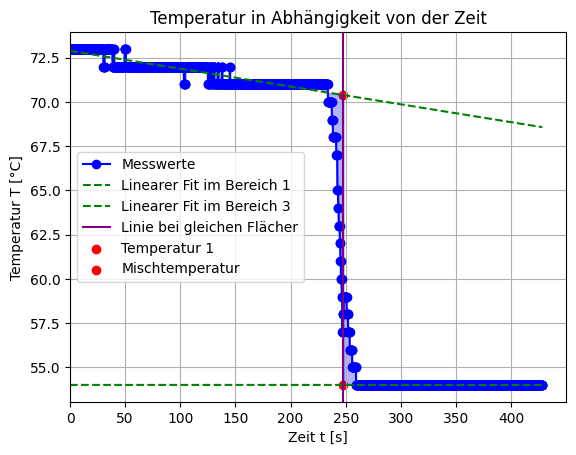

Die Schmelzwärme beträgt (2.71+/-0.21)e+05 J/kg

In [22]:
# Experiment 2: Schmelzwärme von Eis

#Code Auswertung Exp2

me = ufloat(23.7,1) # masse eis
md = ufloat(211.3, 0.05) # masse dewar in g
mwd = ufloat(382.8, 0.05) # masse dewar mit wasser in g
mw = mwd-md # masse wasser
Ck = ufloat(100, 10) # wärmekapazität kalorimeter in J/K
cw = float(4.19*10**3) # spezifische Wärem Wasser, in J/kg*K


df = pd.read_csv("schmelzwärme.csv", sep=',', decimal='.', engine='python')
T = df.iloc[:, -2].to_numpy()
t = df["Time since start of measurement"].to_numpy()

# fits 
#I = np.where(t <= 914)[0] # hier die uhrzeit, zu der wir das eis hineingegeben haben, eintragen
#II = np.where(t >= 1060)[0] # zeitpunkt, zu dem das eis weg ist??
I = 914
II = 1060

t0 = 248 # beispielwert zum ausprobieren 

# abschnitt 1
x1 = t[0:I]
y1 = T[0:I]

res1 = linregress(x1, y1)


def linfit1(k, x1, d):
    return k*x1 + d

#fit1 = Model(linfit1)
#result = fit1.fit(y1, x1, k=1, d=0)
#result.fit_result()
#y1_fit = result.best_fit

y1_fit = res1.slope*t + res1.intercept

x1_plot = t 
y1_plot = y1_fit 
T_1 = res1.slope*t0 + res1.intercept 
#x1_plot = np.linspace(t.min(), t.max(), 100)
#y1_plot = result.params['k'].value * x1_plot + result.params['d'].value
#T_1 = result.params['k'].value * t0 + result.params['d'].value
#T_1_ = ufloat(T_1.nominal_value, ) # T_1 mit eigener Unsicherheit, könnten wir aus dem fit nehmen??

# abschnitt 3
x3 = t[II:]
y3 = T[II:]

#def linfit3(a, x3, b):
    #return a*x3 + b 

#fit3 = Model(linfit3) 
#result = fit3.fit(y3, x3, a=1, b=0)
#result.fit_result()
#y3_fit = result.best_fit

#x3_plot = np.linspace(t.min(), t.max(), 100)
#y3_plot = result.params['a'].value * x3_plot + result.params['b'].value
#T_m = result.params['a'] * t0 + result.params['b'].value
#T_m_ = ufloat(T_m.nominal_value, ) # T_m mit eigener Unsicherheit

res3 = linregress(x3, y3)
y3_fit = res3.slope*t + res3.intercept
x3_plot = t 
y3_plot = y3_fit
T_m = res3.slope*t0 + res3.intercept

T_S = 0

#Ich nenne hier die Anfangstemperatur T_1 (Fit von I ausgewertet bei t0) und die Mischtemperatur T_m (Fit von III ausgewertet bei t0), die Schmelztemperatur T_S ist 0 (nicht sicher, deswegen lasse ich es mal)

S = ((Ck + mw * cw) * (T_1 - T_m) - me * cw * (T_m - T_S))/me # hier ev T_1 und T_m ändern mit _ danach für eigene Unsicherheiten
S_nom = S.nominal_value

# plot
plt.figure()
plt.plot(t, T, marker='o', label="Messwerte", color='blue')
plt.plot(x1_plot, y1_plot, "--", label="Linearer Fit im Bereich 1", color='green')
plt.plot(x3_plot, y3_plot, "--", label="Linearer Fit im Bereich 3", color='green')
plt.axvline(t0, linestyle="-", label="Linie bei gleichen Flächer", color='purple') # einsetzen!!
plt.xlabel("Zeit t [s]")
plt.scatter(t0, T_1, marker="o", color='red', label="Temperatur 1")
plt.scatter(t0, T_m, marker="o", color='red', label="Mischtemperatur")
#plt.scatter(t0, S_nom, marker="o", color='red', label="Spezifische Schmelzwärme")
plt.fill_between(t[I:II], T[I:II], y1_plot[I:II], where=(t[I:II] <= t0), alpha=0.3, color='blue')
plt.fill_between(t[I:II], T[I:II], y3_plot[I:II], where=(t[I:II] >= t0), alpha=0.3, color='blue')
plt.ylabel("Temperatur T [°C]")
plt.title("Temperatur in Abhängigkeit von der Zeit")
plt.xlim(left=0)
plt.legend()
plt.grid(True)
plt.show()

r2o = res1.rvalue**2
r2u = res3.rvalue**2

#print(f"Die Schmelzwärme beträgt {S} J/kg")
display(Markdown(rf"Die Schmelzwärme beträgt {S} J/kg"))




    



### Diskussion